***
# Streamlit app - export my model
Uses the original 80/20 stratified split, with random_state=42.
Creates the same three engineered features.
Fits scaling and encoding inside the pipeline using training data only.
Trains balanced logistic regression, keeping threshold 0.57.
Exports the fitted model with feature_mode="lavanya_v2".
***

In [1]:

# all imports
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import clone

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from pycaret.classification import ClassificationExperiment
from flaml import AutoML
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report



In [2]:
# Load fresh data
df = pd.read_csv("data/telecom_users.csv")
df = df.drop(columns=["Unnamed: 0"])

# Convert charges to numbers
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="raise")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Previously checked assumption for new customers
mask = df["TotalCharges"].isna() & df["tenure"].eq(0)
df.loc[mask, "TotalCharges"] = 0

# Separate features and target
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

# Preserve our original split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Remaining missing values:", X_train.isna().sum().sum())

Training shape: (4788, 19)
Remaining missing values: 0


# Main Idea here is
- Feature exploration: distributions and churn rates, using training data.
- Feature engineering: compare original and engineered features.
- Model comparison: cross-validation scores with error bars.
- Validation: precision–recall curves, ROC curves, and threshold comparisons.
- Final evaluation: confusion matrix.

#### First, train baseline logistic regression using the original features and five-fold cross-validation. Preprocessing is fitted separately inside each fold.


In [3]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    column for column in X_train.columns
    if column not in numeric_features
]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"),
     categorical_features)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [4]:
# baseline_pipeline = Pipeline([
#     ("preprocessor", clone(preprocessor)),
#     ("model", LogisticRegression(
#         max_iter=2000,
#         random_state=42
#     ))
# ])

# baseline_scores = cross_validate(
#     baseline_pipeline,
#     X_train,
#     y_train,
#     cv=cv,
#     scoring=scoring,
#     n_jobs=2
# )

# baseline_fold_scores = pd.DataFrame({
#     metric: baseline_scores[f"test_{metric}"]
#     for metric in scoring
# })

# baseline_summary = pd.DataFrame({
#     "Mean": baseline_fold_scores.mean(),
#     "Std": baseline_fold_scores.std(ddof=0)
# })

# display(baseline_summary.round(4))

In [5]:
# # Plot the mean scores with error bars showing variation across folds
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

# fig, ax = plt.subplots(figsize=(8, 4))

# bars = ax.bar(
#     baseline_summary.index,
#     baseline_summary["Mean"],
#     yerr=baseline_summary["Std"],
#     capsize=5,
#     color=["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756"]
# )

# ax.bar_label(bars, fmt="%.3f", padding=8)
# ax.set_ylim(0, 1)
# ax.set_ylabel("Score")
# ax.set_title("Baseline Logistic Regression — Training Cross-Validation")
# ax.grid(False)

# plt.tight_layout()
# plt.show()

### Feature Engineering

In [6]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

###### explore customer clusters before feature engineering

In [7]:
# #First, prepare the training features only, excluding Churn. We’ll use the original 19 features.
# cluster_preprocessor = clone(preprocessor)

# X_cluster = cluster_preprocessor.fit_transform(X_train)

# print("Clustering input shape:", X_cluster.shape)

In [8]:
# # Then compare 2–8 clusters using an elbow plot
# cluster_counts = range(2, 9)
# inertias = []

# for k in cluster_counts:
#     model = KMeans(
#         n_clusters=k,
#         random_state=42,
#         n_init=10
#     )
#     model.fit(X_cluster)
#     inertias.append(model.inertia_)

# fig, ax = plt.subplots(figsize=(7, 4))

# ax.plot(
#     list(cluster_counts),
#     inertias,
#     marker="o",
#     color="#4C78A8"
# )

# ax.set_xlabel("Number of clusters")
# ax.set_ylabel("Inertia")
# ax.set_title("K-Means Elbow Plot — Training Customers")
# ax.set_xticks(list(cluster_counts))
# ax.grid(False)

# plt.tight_layout()
# plt.show()

In [9]:
# # 3 is a reasonable starting choice
# kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# cluster_labels = kmeans.fit_predict(X_cluster)

# cluster_data = X_train.copy()
# cluster_data["Cluster"] = cluster_labels
# cluster_data["Churn"] = y_train

# cluster_summary = (
#     cluster_data.groupby("Cluster")
#     .agg(
#         Customers=("Churn", "size"),
#         Churn_rate=("Churn", "mean")
#     )
# )

# cluster_summary["Churn_rate"] *= 100

# display(cluster_summary.round(2))

In [10]:
# # plot
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# sizes = axes[0].bar(
#     cluster_summary.index.astype(str),
#     cluster_summary["Customers"],
#     color="#4C78A8"
# )
# axes[0].bar_label(sizes, padding=3)
# axes[0].set_title("Customers per Cluster")
# axes[0].set_ylabel("Customer count")

# rates = axes[1].bar(
#     cluster_summary.index.astype(str),
#     cluster_summary["Churn_rate"],
#     color="#F58518"
# )
# axes[1].bar_label(rates, fmt="%.1f%%", padding=3)
# axes[1].axhline(
#     y_train.mean() * 100,
#     color="red",
#     linestyle="--",
#     label="Overall training churn rate"
# )
# axes[1].set_ylim(0, 100)
# axes[1].set_title("Churn Rate per Cluster")
# axes[1].set_ylabel("Churn (%)")
# axes[1].legend()

# for ax in axes:
#     ax.set_xlabel("Cluster")
#     ax.grid(False)

# plt.tight_layout()
# plt.show()

The clusters have clearly different churn rates:

Cluster 0: 2,122 customers, 44.30% churn — highest risk.
Cluster 1: 1,614 customers, 15.49% churn.
Cluster 2: 1,052 customers, 7.51% churn — lowest risk

In [11]:
# # let’s see which attributes distinguish them
# #First, compare the numeric features
# numeric_profile = (
#     cluster_data.groupby("Cluster")[numeric_features].mean()
# )

# display(numeric_profile.round(2))

# fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# for ax, feature in zip(axes, numeric_features):
#     bars = ax.bar(
#         numeric_profile.index.astype(str),
#         numeric_profile[feature],
#         color=["#E45756", "#4C78A8", "#54A24B"]
#     )
#     ax.bar_label(bars, fmt="%.1f", padding=3)
#     ax.set_title(f"Average {feature}")
#     ax.set_xlabel("Cluster")
#     ax.set_ylabel(feature)
#     ax.margins(y=0.15)
#     ax.grid(False)

# plt.tight_layout()
# plt.show()

Cluster 0 — highest churn (44.30%): shortest average tenure (15 months) and monthly charges around 67.65.
Cluster 1 — lower churn (15.49%): longest average tenure (56 months) despite having the highest monthly charges (89.52).
Cluster 2 — lowest churn (7.51%): average tenure of 31 months and the lowest monthly charges (21.08).

These patterns suggest tenure and service type may help explain churn alongside price. Higher monthly charges alone don’t explain the differences.

In [12]:
# # compare the percentage of each category within each cluster:
# category_profiles = []

# for feature in categorical_features:
#     percentages = pd.crosstab(
#         cluster_data[feature],
#         cluster_data["Cluster"],
#         normalize="columns"
#     ) * 100

#     percentages.index = [
#         f"{feature}: {value}" for value in percentages.index
#     ]

#     category_profiles.append(percentages)

# categorical_profile = pd.concat(category_profiles)

# fig, ax = plt.subplots(figsize=(8, 14))

# sns.heatmap(
#     categorical_profile,
#     annot=True,
#     fmt=".0f",
#     cmap="Blues",
#     vmin=0,
#     vmax=100,
#     linewidths=0.5,
#     cbar_kws={"label": "Customers within cluster (%)"},
#     ax=ax
# )

# ax.set_title("Categorical Feature Profiles by Cluster")
# ax.set_xlabel("Cluster")
# ax.set_ylabel("")
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
Cluster 0 — highest churn (44.30%): newer internet customers; 87% have month-to-month contracts, 77% lack online security, and 78% lack technical support. Electronic check is the most common payment method (49%).
Cluster 1 — lower churn (15.49%): longer-tenure internet customers; 75% have one- or two-year contracts, with more security, support, and other add-ons. They pay more monthly but churn less.
Cluster 2 — lowest churn (7.51%): 100% have no internet service, explaining their low monthly charges. About 67% have one- or two-year contracts.
Gender barely differs across clusters. Paperless billing is also similar between clusters 0 and 1 despite their different churn rates.

These findings suggest testing short tenure × month-to-month contract, internet add-on count, and automatic payment as engineered features.

One consideration: “No internet service” appears in several columns, so this repeated information may strongly influence clustering. The clusters reveal useful patterns, but don’t establish which features independently drive churn.
***

In [13]:
# create three features with clear meanings based on cluster profiles
def engineer_features(X):
    X_new = X.copy()
    # InternetAddonCount: number of internet add-ons; zero includes customers without internet.
    addon_columns = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]

    X_new["InternetAddonCount"] = (
        X_new[addon_columns].eq("Yes").sum(axis=1)
    )
    # AutomaticPayment: 1 means automatic bank transfer or credit card payment.
    X_new["AutomaticPayment"] = (
        X_new["PaymentMethod"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]).astype(int)
    )
    # NewMonthToMonth: 1 means tenure ≤ 6 months and a month-to-month contract.
    # Six months is an initial cutoff to test
    X_new["NewMonthToMonth"] = (
        X_new["tenure"].le(6)
        & X_new["Contract"].eq("Month-to-month")
    ).astype(int)

    return X_new


X_train_engineered = engineer_features(X_train)

new_features = [
    "InternetAddonCount",
    "AutomaticPayment",
    "NewMonthToMonth"
]

display(X_train_engineered[new_features].head())

,InternetAddonCount,AutomaticPayment,NewMonthToMonth
3625,5,0,0
2608,3,1,0
4856,0,1,0
3303,1,0,0
1089,3,1,0


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

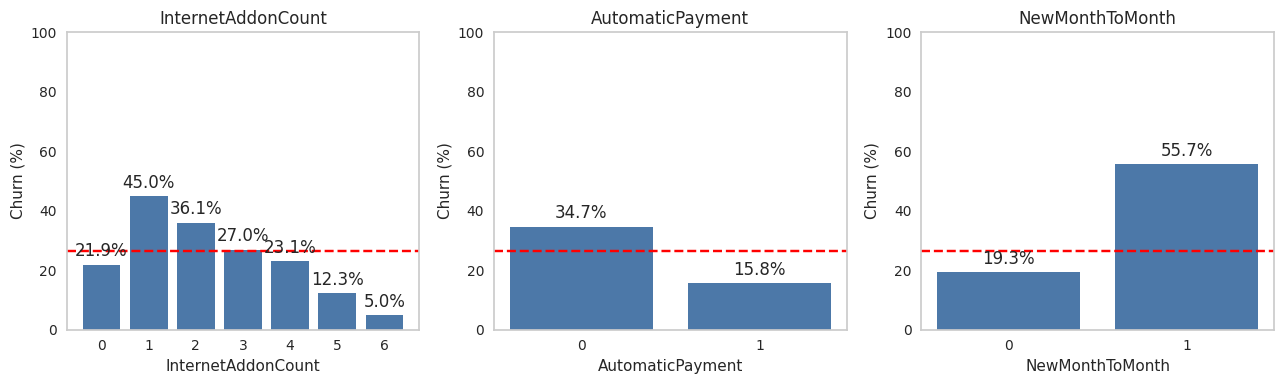

In [14]:
# Plot their churn rates using training data:
feature_data = X_train_engineered[new_features].copy()
feature_data["Churn"] = y_train

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, feature in zip(axes, new_features):
    rates = feature_data.groupby(feature)["Churn"].mean() * 100

    bars = ax.bar(
        rates.index.astype(str),
        rates.values,
        color="#4C78A8"
    )

    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.axhline(
        y_train.mean() * 100, #overall training churn rate.
        color="red",
        linestyle="--"
    )
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("Churn (%)")
    ax.set_ylim(0, 100)
    ax.grid(False)

plt.tight_layout()
plt.show()

***
New month-to-month customers: 55.7% churn.
Automatic payment: 15.8% churn versus 34.7% without it.
Add-on count: churn generally decreases from 1 to 6 add-ons. Zero mixes internet customers without add-ons and customers without internet.
***

#### lets find anomaly?

In [15]:
# # Isolation Forest on the original training features:
# anomaly_detector = IsolationForest(
#     n_estimators=200,
#     contamination="auto",
#     random_state=42,
#     n_jobs=2
# )

# # X_cluster contains preprocessed original training features
# anomaly_labels = anomaly_detector.fit_predict(X_cluster)

# anomaly_data = X_train.copy()
# anomaly_data["Anomaly"] = anomaly_labels == -1
# anomaly_data["AnomalyScore"] = (
#     anomaly_detector.decision_function(X_cluster)
# )

# print("Flagged customers:", anomaly_data["Anomaly"].sum())
# print(
#     "Flagged percentage:",
#     round(anomaly_data["Anomaly"].mean() * 100, 2)
# )

# # Lower scores indicate more unusual customers
# display(
#     anomaly_data.nsmallest(10, "AnomalyScore")[
#         numeric_features + ["InternetService", "Contract", "AnomalyScore"]
#     ]
# )

In [16]:
# fig, ax = plt.subplots(figsize=(8, 4))

# ax.hist(
#     anomaly_data["AnomalyScore"],
#     bins=40,
#     color="#4C78A8",
#     edgecolor="white"
# )

# ax.axvline(
#     0,
#     color="#E45756",
#     linestyle="--",
#     label="Default flagging boundary"
# )

# ax.set_xlabel("Anomaly score — lower means more unusual")
# ax.set_ylabel("Customers")
# ax.set_title("Isolation Forest — Training Customers")
# ax.legend()
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
Flagging 86.95% of customers means the default boundary isn’t useful here. It does not mean most of your data is wrong.

The plot shows a broad score distribution without a clearly separated anomaly group.
Isolation Forest uses all 46 encoded features; unusual category combinations can receive low scores even when their numeric values look ordinary.
The displayed customers don’t show obvious numeric errors.

Keep all customers. For inspection, we can label the lowest-scoring 5%—an exploratory cutoff, not a confirmed anomaly rate.
***

In [17]:
# inspection_cutoff = anomaly_data["AnomalyScore"].quantile(0.05)

# anomaly_data["ReviewFlag"] = (
#     anomaly_data["AnomalyScore"] <= inspection_cutoff
# )

# print("Customers to review:", anomaly_data["ReviewFlag"].sum())

# # Describe the groups using churn only after anomaly detection
# anomaly_data["Churn"] = y_train

# review_summary = (
#     anomaly_data.groupby("ReviewFlag")
#     .agg(
#         Customers=("Churn", "size"),
#         Churn_rate=("Churn", "mean")
#     )
# )

# review_summary["Churn_rate"] *= 100
# display(review_summary.round(2))

***
The 240 customers flagged for review churn less (10.42%) than the other customers (27.35%). Unusual profiles aren’t necessarily high-risk customers. We’ll retain every row.#
***

In [18]:
# # compare logistic regression with and without the three engineered features, using the same folds and model settings.
# engineered_numeric = numeric_features + new_features

# engineered_preprocessor = ColumnTransformer([
#     ("numeric", StandardScaler(), engineered_numeric),
#     ("categorical", OneHotEncoder(handle_unknown="ignore"),
#      categorical_features)
# ])

# engineered_pipeline = Pipeline([
#     ("preprocessor", engineered_preprocessor),
#     ("model", LogisticRegression(
#         max_iter=2000,
#         random_state=42
#     ))
# ])

# engineered_scores = cross_validate(
#     engineered_pipeline,
#     X_train_engineered,
#     y_train,
#     cv=cv,
#     scoring=scoring,
#     n_jobs=2
# )

# engineered_fold_scores = pd.DataFrame({
#     metric: engineered_scores[f"test_{metric}"]
#     for metric in scoring
# })

# comparison = pd.DataFrame({
#     "Original": baseline_fold_scores.mean(),
#     "Engineered": engineered_fold_scores.mean()
# })

# comparison["Change"] = (
#     comparison["Engineered"] - comparison["Original"]
# )

# display(comparison.round(4))


In [19]:
# replacing the above cell for just exporting my final model- since i don't need everything on cross validation
engineered_numeric = numeric_features + new_features

engineered_preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), engineered_numeric),
    ("categorical", OneHotEncoder(handle_unknown="ignore"),
     categorical_features)
])

engineered_pipeline = Pipeline([
    ("preprocessor", engineered_preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

In [20]:
# # Plot the comparison with fold standard deviations:
# means = comparison[["Original", "Engineered"]]

# stds = pd.DataFrame({
#     "Original": baseline_fold_scores.std(ddof=0),
#     "Engineered": engineered_fold_scores.std(ddof=0)
# })

# ax = means.plot.bar(
#     yerr=stds,
#     capsize=4,
#     figsize=(10, 4),
#     color=["#4C78A8", "#F58518"],
#     rot=0
# )

# for container in ax.containers:
#     if isinstance(container, plt.matplotlib.container.BarContainer):
#         ax.bar_label(container, fmt="%.3f", padding=5)

# ax.set_ylim(0, 1)
# ax.set_ylabel("Cross-validation score")
# ax.set_xlabel("")
# ax.set_title("Logistic Regression — Original vs Engineered Features")
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
The engineered features haven’t improved churn F1 at the default threshold:

Precision increased: 0.6519 → 0.6681.
Recall decreased: 0.5477 → 0.5335.
F1 slightly decreased: 0.5946 → 0.5926.
ROC AUC slightly increased: 0.8447 → 0.8473.

***

In [21]:
# # test balanced class weights, which give churners more weight during training. Use the same folds for a fair comparison:
# balanced_results = {}
# balanced_fold_scores = {}

# for name, pipeline, features in [
#     ("Original balanced", baseline_pipeline, X_train),
#     ("Engineered balanced", engineered_pipeline, X_train_engineered)
# ]:
#     candidate = clone(pipeline)
#     candidate.set_params(model__class_weight="balanced")

#     scores = cross_validate(
#         candidate,
#         features,
#         y_train,
#         cv=cv,
#         scoring=scoring,
#         n_jobs=2
#     )

#     fold_scores = pd.DataFrame({
#         metric: scores[f"test_{metric}"]
#         for metric in scoring
#     })

#     balanced_fold_scores[name] = fold_scores
#     balanced_results[name] = fold_scores.mean()

# all_results = pd.DataFrame({
#     "Original": baseline_fold_scores.mean(),
#     "Engineered": engineered_fold_scores.mean(),
#     **balanced_results
# })

# display(all_results.round(4))

In [22]:
# # plot
# ax = all_results.loc[["precision", "recall", "f1"]].plot.bar(
#     figsize=(10, 4),
#     color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"],
#     rot=0
# )

# for container in ax.containers:
#     ax.bar_label(container, fmt="%.3f", padding=3)

# ax.set_ylim(0, 1)
# ax.set_ylabel("Mean cross-validation score")
# ax.set_xlabel("")
# ax.set_title("Logistic Regression — Features and Class Weights")
# ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
Balanced class weights made the biggest improvement.

Recall rose from 54.8% to about 80% — we detect more churners.
Precision fell from 65.2% to about 52% — more flagged customers actually stay.
F1 improved from 0.5946 to 0.6288 with balanced weights and engineered features.
Feature engineering added only 0.0019 F1 over the original balanced model, so its benefit remains small.
ROC AUC stayed similar: class weighting mainly changed the precision–recall trade-off at the default threshold.

Keep both balanced models as references. Next, we’ll compare AutoML candidates using the same training data, folds, and churn-class F1, then plot their results.
***

### AutoML

In [23]:
# # Prepare the data without applying our sklearn preprocessor. FLAML handles its own feature conversion
# X_flaml = X_train_engineered.copy()

# for column in categorical_features:
#     X_flaml[column] = X_flaml[column].astype("category")

# print("FLAML training shape:", X_flaml.shape)

In [24]:
# # start the search
# automl_engineered = AutoML()

# automl_engineered.fit(
#     X_train=X_flaml,
#     y_train=y_train,
#     task="classification",
#     metric="f1",
#     time_budget=1800,       # 30-minute search budget
#     eval_method="cv",
#     split_type=cv,          # Same five folds as our baseline
#     sample=False,           # Use all fold-training rows
#     estimator_list=[
#         "lgbm",
#         "xgboost",
#         "catboost",
#         "rf",
#         "extra_tree",
#         "lrl2"
#     ],
#     n_jobs=2,
#     seed=42,
#     verbose=2,
#     log_file_name="flaml_engineered_30min.log"
# )

In [25]:
# print("Best model:", automl_engineered.best_estimator)
# print("Best parameters:", automl_engineered.best_config)
# print("Best search CV F1:", round(1 - automl_engineered.best_loss, 4))

FLAML selected L2 logistic regression, with C = 0.2242 and search CV F1 0.6165.

Original balanced logistic regression: 0.6269
Engineered balanced logistic regression: 0.6288
FLAML winner: 0.6165

So the 30-minute search didn’t beat our balanced logistic regression.

In [26]:
# # LDA model is not availale in FLAML
# # let’s tune LDA on the engineered features using the same folds:
# lda_pipeline = Pipeline([
#     ("preprocessor", clone(engineered_preprocessor)),
#     ("model", LinearDiscriminantAnalysis(solver="lsqr"))
# ])

# lda_search = GridSearchCV(
#     estimator=lda_pipeline,
#     param_grid={
#         "model__shrinkage": [
#             None, "auto", 0.1, 0.3, 0.5, 0.6, 0.7, 0.9  # Shrinkage stabilizes LDA’s covariance estimates
#         ]
#     },
#     scoring=scoring,
#     refit="f1",
#     cv=cv,
#     n_jobs=1
# )

# lda_search.fit(X_train_engineered, y_train)

# print("Best LDA parameters:", lda_search.best_params_)
# print("Best search CV F1:", round(lda_search.best_score_, 4))

***
LDA’s F1 of 0.6282 is almost identical to balanced logistic regression’s 0.6288
***

In [27]:
# # plot their fold scores to see the variation
# best_lda_index = lda_search.best_index_

# lda_f1_scores = [
#     lda_search.cv_results_[f"split{i}_test_f1"][best_lda_index]
#     for i in range(cv.n_splits)
# ]

# f1_folds = pd.DataFrame({
#     "Original balanced LR":
#         balanced_fold_scores["Original balanced"]["f1"].to_numpy(),
#     "Engineered balanced LR":
#         balanced_fold_scores["Engineered balanced"]["f1"].to_numpy(),
#     "Engineered LDA": lda_f1_scores
# }, index=range(1, cv.n_splits + 1))

# display(f1_folds.round(4))

# fig, ax = plt.subplots(figsize=(9, 4))

# for name, color in zip(
#     f1_folds.columns,
#     ["#4C78A8", "#F58518", "#54A24B"]
# ):
#     ax.plot(
#         f1_folds.index,
#         f1_folds[name],
#         marker="o",
#         label=f"{name} (mean={f1_folds[name].mean():.4f})",
#         color=color
#     )

# ax.set_xlabel("Fold")
# ax.set_ylabel("Churn F1")
# ax.set_title("Model Comparison Across the Same Five Folds")
# ax.set_xticks(f1_folds.index)
# ax.legend()
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
Neither model wins consistently: LDA leads in folds 1, 3, and 4; engineered balanced LR leads in folds 2 and 5. Their mean scores remain very close.
***

In [28]:
# # generate out-of-fold probabilities: each customer is predicted by a model trained without that customer.
# #  We’ll use these to explore thresholds.

# threshold_models = {
#     "Original balanced LR": (
#         clone(baseline_pipeline).set_params(
#             model__class_weight="balanced"
#         ),
#         X_train
#     ),
#     "Engineered balanced LR": (
#         clone(engineered_pipeline).set_params(
#             model__class_weight="balanced"
#         ),
#         X_train_engineered
#     ),
#     "Engineered LDA": (
#         clone(lda_search.best_estimator_),
#         X_train_engineered
#     )
# }

# oof_probabilities = {}

# for name, (model, features) in threshold_models.items():
#     oof_probabilities[name] = cross_val_predict(
#         model,
#         features,
#         y_train,
#         cv=cv,
#         method="predict_proba",
#         n_jobs=1
#     )[:, 1]

# threshold_rows = []

# for name, probabilities in oof_probabilities.items():
#     for step in range(10, 91):
#         threshold = step / 100
#         predictions = (probabilities >= threshold).astype(int)

#         threshold_rows.append({
#             "Model": name,
#             "Threshold": threshold,
#             "Precision": precision_score(
#                 y_train, predictions, zero_division=0
#             ),
#             "Recall": recall_score(
#                 y_train, predictions, zero_division=0
#             ),
#             "F1": f1_score(y_train, predictions, zero_division=0)
#         })

# threshold_results = pd.DataFrame(threshold_rows)

# best_thresholds = threshold_results.loc[
#     threshold_results.groupby("Model")["F1"].idxmax()
# ]

# display(best_thresholds.round(4))

***
Engineered balanced LR at threshold 0.57 is our leading candidate, but the differences remain small:

Engineered balanced LR: F1 0.6368, precision 55.9%, recall 74.0%.
Engineered LDA: F1 0.6357, precision 56.7%, recall 72.3%.
Original balanced LR: F1 0.6342, precision 55.3%, recall 74.3%.
***

In [29]:
# # Before selecting the final model, let’s plot precision and recall alongside F1 for engineered LR:
# lr_thresholds = threshold_results[
#     threshold_results["Model"] == "Engineered balanced LR"
# ]

# fig, ax = plt.subplots(figsize=(8, 4))

# for metric, color in [
#     ("Precision", "#4C78A8"),
#     ("Recall", "#F58518"),
#     ("F1", "#54A24B")
# ]:
#     ax.plot(
#         lr_thresholds["Threshold"],
#         lr_thresholds[metric],
#         label=metric,
#         color=color
#     )

# ax.axvline(
#     0.57,
#     color="#B279A2",
#     linestyle="--",
#     label="Selected threshold: 0.57"
# )

# ax.set_xlabel("Churn probability threshold")
# ax.set_ylabel("Out-of-fold score")
# ax.set_ylim(0, 1)
# ax.set_title("Engineered Balanced LR — Threshold Trade-off")
# ax.legend()
# ax.grid(False)

# plt.tight_layout()
# plt.show()


***
Lower thresholds: catch more churners, but flag more customers who stay.
Higher thresholds: improve precision, but miss more churners.
At 0.57: precision is 55.9%, recall 74.0%, and F1 0.6368.
F1 has a broad plateau: 0.57 is the measured maximum, but nearby thresholds perform similarly.
***

In [30]:
# # fit the selected model on all 4,788 training customers, keeping threshold 0.57 fixed, and evaluate the existing test split.
# final_model = clone(
#     threshold_models["Engineered balanced LR"][0]
# )

# final_threshold = 0.57

# final_model.fit(X_train_engineered, y_train)

# X_test_engineered = engineer_features(X_test)

# positive_class_index = list(final_model.classes_).index(1)

# test_probabilities = final_model.predict_proba(
#     X_test_engineered
# )[:, positive_class_index]

# test_predictions = (
#     test_probabilities >= final_threshold
# ).astype(int)

# test_metrics = pd.Series({
#     "Accuracy": accuracy_score(y_test, test_predictions),
#     "Precision": precision_score(
#         y_test, test_predictions, zero_division=0
#     ),
#     "Recall": recall_score(
#         y_test, test_predictions, zero_division=0
#     ),
#     "F1": f1_score(y_test, test_predictions, zero_division=0),
#     "ROC AUC": roc_auc_score(y_test, test_probabilities)
# })

# display(test_metrics.round(4))

In [31]:
# replacing the above cell for streamlit 
# Train the selected V2 model using training data only
final_model = clone(engineered_pipeline).set_params(
    model__class_weight="balanced"
)

final_threshold = 0.57

final_model.fit(X_train_engineered, y_train)

print("V2 model trained and ready to export.")

V2 model trained and ready to export.


***
Your model detects 71.1% of churners, with 54.7% precision—about 55% of flagged customers actually churned.

Test F1: 0.6183, compared with threshold-selection F1 0.6368.
Accuracy: 76.7%.
ROC AUC: 0.8334.

Compared with notebook 1’s LDA result (F1 ≈ 0.5831), this follow-up score is higher by about 0.035, with similar recall and better precision.
***

In [32]:
# # plot confusion matrix
# fig, ax = plt.subplots(figsize=(6, 5))

# ConfusionMatrixDisplay.from_predictions(
#     y_test,
#     test_predictions,
#     labels=[0, 1],
#     display_labels=["Stayed", "Churned"],
#     cmap="Blues",
#     values_format="d",
#     ax=ax
# )

# ax.set_title("Follow-up Test — Engineered Balanced LR, Threshold 0.57")
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
693 customers stayed and were correctly predicted to stay.
187 customers stayed but were incorrectly flagged as churners.
92 customers churned and were missed.
226 customers churned and were correctly detected.

The model flagged 413 customers, of whom 226 actually churned.
Compared with notebook 1’s LDA, it produced 49 fewer false alarms, while detecting 2 fewer churners. This explains the improved precision and F1, with nearly unchanged recall.
***

In [33]:
# # plot which features push the fitted model toward or away from churn using its logistic regression coefficients.
# feature_names = (
#     final_model.named_steps["preprocessor"].get_feature_names_out()
# )

# coefficients = pd.Series(
#     final_model.named_steps["model"].coef_[0],
#     index=feature_names,
#     name="Coefficient"
# )

# # Show the 15 largest coefficients by absolute magnitude
# top_features = coefficients.loc[
#     coefficients.abs().nlargest(15).index
# ].sort_values()

# labels = (
#     top_features.index
#     .str.replace("numeric__", "", regex=False)
#     .str.replace("categorical__", "", regex=False)
# )

# fig, ax = plt.subplots(figsize=(10, 6))

# bars = ax.barh(
#     labels,
#     top_features.values,
#     color=[
#         "#E45756" if value > 0 else "#4C78A8"
#         for value in top_features.values
#     ]
# )

# ax.bar_label(bars, fmt="%.2f", padding=4)
# ax.axvline(0, color="gray", linewidth=1)
# ax.set_xlabel("Logistic regression coefficient")
# ax.set_title("Largest Coefficients — Final Churn Model")
# ax.margins(x=0.2)
# ax.grid(False)

# plt.tight_layout()
# plt.show()

In [34]:
# # Let’s explain the highest-scoring test customer.
# # compare their features with the average transformed training profile.
# # Select the highest-scoring test customer
# customer_position = test_probabilities.argmax()
# customer = X_test_engineered.iloc[[customer_position]]
# customer_index = customer.index[0]

# print("Customer ID:", df.loc[customer_index, "customerID"])
# print("Model churn score:", round(test_probabilities[customer_position], 4))
# print("Actual churn:", "Yes" if y_test.loc[customer_index] == 1 else "No")

# display(customer.T)

In [35]:
# # Calculate each feature’s contribution to the model’s score:
# fitted_preprocessor = final_model.named_steps["preprocessor"]
# fitted_lr = final_model.named_steps["model"]

# training_encoded = fitted_preprocessor.transform(X_train_engineered)
# customer_encoded = fitted_preprocessor.transform(customer)

# training_average = training_encoded.mean(axis=0)
# training_average = (
#     training_average.A1
#     if hasattr(training_average, "A1")
#     else training_average.ravel()
# )

# customer_values = (
#     customer_encoded.toarray().ravel()
#     if hasattr(customer_encoded, "toarray")
#     else customer_encoded.ravel()
# )

# contributions = pd.Series(
#     (customer_values - training_average) * fitted_lr.coef_[0],
#     index=fitted_preprocessor.get_feature_names_out()
# )

# top_contributions = contributions.loc[
#     contributions.abs().nlargest(12).index
# ].sort_values()

# labels = (
#     top_contributions.index
#     .str.replace("numeric__", "", regex=False)
#     .str.replace("categorical__", "", regex=False)
# )

# fig, ax = plt.subplots(figsize=(10, 6))

# bars = ax.barh(
#     labels,
#     top_contributions.values,
#     color=[
#         "#E45756" if value > 0 else "#4C78A8"
#         for value in top_contributions.values
#     ]
# )

# ax.bar_label(bars, fmt="%.2f", padding=4)
# ax.axvline(0, color="gray")
# ax.set_xlabel("Contribution to log-odds relative to training average")
# ax.set_title(f"Individual Prediction — Customer {customer_index}")
# ax.margins(x=0.2)
# ax.grid(False)

# plt.tight_layout()
# plt.show()

***
For customer 1988, the strongest upward contributions are:

New customer on a month-to-month contract.
Short tenure, compared with the training average.
Month-to-month contract.
Higher monthly charges.
Fiber optic service and no online security also contribute.

Some labels describe an absent attribute:

Contract_Two year is red because this customer doesn’t have a two-year contract.
InternetService_DSL is red because they don’t use DSL.
SeniorCitizen_0 being red indicates they are a senior citizen.

The plotted contributions are all positive because these are the 12 largest by absolute magnitude; smaller negative contributions may exist. Related features share information, so don’t count tenure, contract, and NewMonthToMonth as three independent reasons.
***

In [36]:
# print(classification_report(
#     y_test,
#     test_predictions,
#     target_names=["Stayed", "Churned"],
#     digits=4,
#     zero_division=0
# ))

***
Cleaned the data and explored churn patterns.
Explored clusters and anomalies; retained all customers.
Tested feature engineering, balanced weights, FLAML, and LDA.
Selected engineered balanced logistic regression, threshold 0.57.
Evaluated it: F1 0.6183, precision 54.7%, recall 71.1%.
Explained feature effects and an individual prediction.

feature engineering gave only a small improvement, and the test result is a follow-up evaluation on a previously viewed test set.
***

### Conclusion

- Selected model: balanced logistic regression with engineered features and threshold 0.57.
- Test results: F1 = 0.6183, precision = 54.7%, recall = 71.1%, and ROC AUC = 0.8334.
- The model detected 226 of 318 churners, missed 92, and incorrectly flagged 187 customers who stayed.
- Contract type, tenure, monthly charges, and internet services contributed to the model’s predictions; these are associations, not causal explanations.
- Balanced class weights improved churn detection; feature engineering added only a small improvement in development F1.
- Clustering revealed customer groups with different churn rates. Anomaly detection did not justify removing customers.
- The 30-minute FLAML search did not outperform our balanced logistic regression in development F1.
- The test results are a follow-up evaluation because this test set was previously examined in notebook 1.

### Proposed Retention Actions

- Offer onboarding support to new month-to-month customers.
- Review affordable plans for customers with high monthly charges.
- Check service quality and unresolved complaints for flagged internet customers.
- Offer support sessions where appropriate.
- Test voluntary loyalty offers.

These actions are hypotheses based on observed associations.
Validate them through a randomized experiment, measuring churn reduction
and the cost per additional retained customer.

## Export V2 for the group Streamlit app
Place model_support.py next to this notebook. Run after final_model is fitted. This saves the existing fitted model without retraining.

In [37]:
from sklearn.preprocessing import FunctionTransformer
from lavanya_features import prepare_lavanya_inputs
from model_support import export_bundle
# Wrap the already-fitted model. Do not fit this wrapper again.
app_pipeline = Pipeline([
    ("customer_features", FunctionTransformer(
        prepare_lavanya_inputs,
        validate=False
    )),
    ("fitted_model", final_model)
])

export_bundle(
    path="models/lavanya.joblib",
    model=app_pipeline,
    member="Lavanya",
    threshold=final_threshold,
    positive_label=1
)

print("Lavanya's model exported.")


Lavanya's model exported.


In [38]:
#check if the model is saved!
from pathlib import Path

model_path = Path("models/lavanya.joblib")
print("Model saved:", model_path.exists())
print("Location:", model_path.resolve())

Model saved: True
Location: /home/lavanya/telco_churn_project/telco_group_app/models/lavanya.joblib
